<a href="https://colab.research.google.com/github/satya0212/Time_series_forcasting/blob/main/VAR_tsf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests,adfuller
from tqdm import tqdm_notebook
from itertools import product
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [ ]:
filepath = 'https://raw.githubusercontent.com/selva86/datasets/master/Raotbl6.csv'
macro_data = pd.read_csv(filepath, parse_dates=['date'], index_col='date')
print(macro_data.shape)  # (123, 8)
macro_data.head()


(123, 8)


,rgnp,pgnp,ulc,gdfco,gdf,gdfim,gdfcf,gdfce
date,,,,,,,,
1959-01-01,1606.4,1608.3,47.5,36.9,37.4,26.9,32.3,23.1
1959-04-01,1637.0,1622.2,47.5,37.4,37.5,27.0,32.2,23.4
1959-07-01,1629.5,1636.2,48.7,37.6,37.6,27.1,32.4,23.4
1959-10-01,1643.4,1650.3,48.8,37.7,37.8,27.1,32.5,23.8
1960-01-01,1671.6,1664.6,49.1,37.8,37.8,27.2,32.4,23.8


In [ ]:
adfuller_result_1 = adfuller(macro_data['rgnp'].diff()[1:])
print('realgdp')
print(f'ADF Statistic: {adfuller_result_1[0]}')
print(f'p-value: {adfuller_result_1[1]}')
print('\n.............\n')
adfuller_result_2 = adfuller(macro_data['ulc'].diff()[1:])
print('realcons')
print(f'ADF Statistic: {adfuller_result_2[0]}')
print(f'p-value: {adfuller_result_2[1]}')

realgdp
ADF Statistic: -5.427594381007333
p-value: 2.9633019848469254e-06

.............

realcons
ADF Statistic: -3.576080473150911
p-value: 0.006235131830238172


In [ ]:
print('rgnp causes ulc?\n')
print('.............')
granger1 = grangercausalitytests(macro_data[['ulc','rgnp']],4)

print('\nulc causes rgnp?\n')
print('..........')
granger2 = grangercausalitytests(macro_data[['rgnp','ulc']],4)


rgnp causes ulc?

.............

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=22.3802 , p=0.0000  , df_denom=119, df_num=1
ssr based chi2 test:   chi2=22.9444 , p=0.0000  , df=1
likelihood ratio test: chi2=21.0242 , p=0.0000  , df=1
parameter F test:         F=22.3802 , p=0.0000  , df_denom=119, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=7.7188  , p=0.0007  , df_denom=116, df_num=2
ssr based chi2 test:   chi2=16.1029 , p=0.0003  , df=2
likelihood ratio test: chi2=15.1179 , p=0.0005  , df=2
parameter F test:         F=7.7188  , p=0.0007  , df_denom=116, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=7.5231  , p=0.0001  , df_denom=113, df_num=3
ssr based chi2 test:   chi2=23.9675 , p=0.0000  , df=3
likelihood ratio test: chi2=21.8515 , p=0.0001  , df=3
parameter F test:         F=7.5231  , p=0.0001  , df_denom=113, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test

In [ ]:
macro_data = macro_data[['ulc','rgnp']]
print(macro_data.shape)

(123, 2)


In [ ]:
train_df = macro_data[:-12]
test_df = macro_data[-12:]

In [ ]:
model = VAR(train_df.diff()[1:])

In [ ]:
sorted_order = model.select_order(maxlags=20)
print(sorted_order.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        6.778       6.834       878.3       6.800
1        5.988      6.154*       398.5       6.055
2        5.942       6.220       380.9       6.054
3        5.933       6.322       377.4       6.090
4       5.793*       6.293      328.5*      5.995*
5        5.873       6.484       356.3       6.120
6        5.828       6.550       341.1       6.119
7        5.894       6.727       365.0       6.230
8        5.890       6.835       364.8       6.271
9        5.942       6.998       385.8       6.368
10       5.930       7.097       382.9       6.401
11       5.913       7.191       378.5       6.428
12       5.885       7.274       370.7       6.445
13       5.925       7.424       388.6       6.529
14       5.882       7.493       376.0       6.532
15       5.950       7.672       406.9       6.644
16       5.933       7.766     

In [ ]:
var_model = VARMAX(train_df, order=(4,0),enforce_stationarity=True)
fitted_model = var_model.fit(disp=False)
print(fitted_model.summary())

                           Statespace Model Results                           
Dep. Variable:        ['ulc', 'rgnp']   No. Observations:                  111
Model:                         VAR(4)   Log Likelihood              -11856.862
                          + intercept   AIC                          23755.725
Date:                Thu, 20 Nov 2025   BIC                          23812.625
Time:                        21:53:31   HQIC                         23778.807
Sample:                    01-01-1959                                         
                         - 07-01-1986                                         
Covariance Type:                  opg                                         
Ljung-Box (L1) (Q):          36.74, 106.09   Jarque-Bera (JB):         23.84, 13.81
Prob(Q):                        0.00, 0.00   Prob(JB):                   0.00, 0.00
Heteroskedasticity (H):         1.67, 0.27   Skew:                      0.69, -0.86
Prob(H) (two-sided):            0.12,

In [ ]:
n_forecast = 12
forecast = fitted_model.get_forecast(steps=n_forecast)
prediction = forecast.predicted_mean

In [ ]:
prediction.columns = ['ulc_predicted','rgnp_predicted']
prediction

,ulc_predicted,rgnp_predicted
1986-10-01,166.310528,3565.593645
1987-01-01,245.362789,3756.610096
1987-04-01,47.250981,3551.338921
1987-07-01,269.971360,3865.049128
1987-10-01,147.416092,3474.807441
1988-01-01,171.355744,3770.403181
1988-04-01,153.515094,3630.505898
1988-07-01,210.632678,3733.420984
1988-10-01,142.634921,3562.977954
1989-01-01,197.644556,3771.752258


In [ ]:
test_vs_prediction = pd.concat([test_df,prediction])


<Axes: >

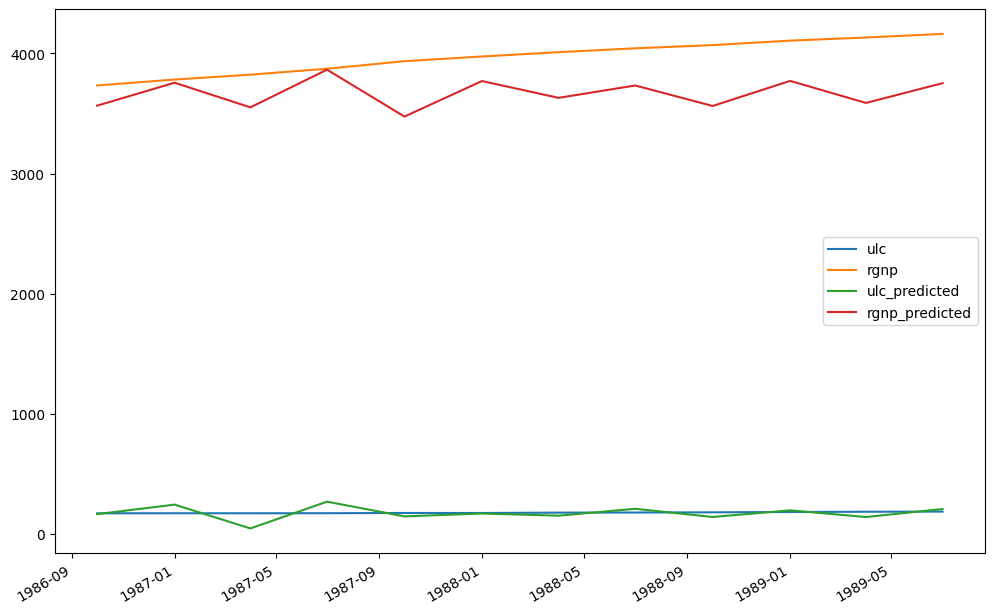

In [ ]:
test_vs_prediction.plot(figsize=(12,8))

In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt
rmse_ulc = sqrt(mean_squared_error(test_df['ulc'],prediction['ulc_predicted']))
rmse_rgnp = sqrt(mean_squared_error(test_df['rgnp'],prediction['rgnp_predicted']))

In [ ]:
print('mean value of ulc is: {}, rmse of ulc is: {}'.format(test_df['ulc'].mean(),rmse_ulc))
print('mean value of rgnp is: {}, rmse of rgnp is: {}'.format(test_df['rgnp'].mean(),rmse_rgnp))

mean value of ulc is: 178.56666666666663, rmse of ulc is: 55.405071100320875
mean value of rgnp is: 3970.691666666667, rmse of rgnp is: 345.2805616239218
